In [23]:
import os, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input



In [24]:


TRAIN_DIR  = r"C:\Users\Basant\Desktop\pbl\pimple_detection\dataset\train_resized"
MODEL_PATH = r"C:\Users\Basant\Desktop\pbl\pimple_model.keras"

BASE_DIR    = r"C:\Users\Basant\Desktop\pbl\pimple_detection\dataset"
SPLIT_TRAIN = BASE_DIR + r"\split_train"
TEST_DIR    = BASE_DIR + r"\test"

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 25

CLASS_NAMES = [
    "bacterial_acne",
    "dietary_acne",
    "hormonal_acne",
    "hygiene_acne",
    "normal_skin",
    "stress_acne"
]



In [25]:
print("STEP 1 - Creating fresh 80/20 split...")


for folder in [SPLIT_TRAIN, TEST_DIR]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
        print(f"  Deleted old folder: {folder}")

random.seed(42)

for cls in CLASS_NAMES:
    src = os.path.join(TRAIN_DIR, cls)
    if not os.path.isdir(src):
        print(f"  Skipping {cls} — folder not found")
        continue

    files = [f for f in os.listdir(src)
             if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    random.shuffle(files)

    n_test      = int(len(files) * 0.20)
    test_files  = files[:n_test]
    train_files = files[n_test:]

    os.makedirs(os.path.join(SPLIT_TRAIN, cls), exist_ok=True)
    os.makedirs(os.path.join(TEST_DIR, cls),    exist_ok=True)

    for f in train_files:
        shutil.copy(os.path.join(src, f), os.path.join(SPLIT_TRAIN, cls, f))
    for f in test_files:
        shutil.copy(os.path.join(src, f), os.path.join(TEST_DIR, cls, f))

    print(f"  {cls:<22}  train={len(train_files)}  test={len(test_files)}")

print("  Done!\n")



STEP 1 - Creating fresh 80/20 split...
  Deleted old folder: C:\Users\Basant\Desktop\pbl\pimple_detection\dataset\split_train
  Deleted old folder: C:\Users\Basant\Desktop\pbl\pimple_detection\dataset\test
  bacterial_acne          train=288  test=72
  dietary_acne            train=288  test=72
  hormonal_acne           train=288  test=72
  hygiene_acne            train=288  test=72
  normal_skin             train=288  test=72
  stress_acne             train=288  test=72
  Done!



In [26]:
print("STEP 2 - Loading data...")

train_data = ImageDataGenerator(
    preprocessing_function = preprocess_input,   
    rotation_range         = 20,
    zoom_range             = 0.2,
    horizontal_flip        = True,
    width_shift_range      = 0.1,
    height_shift_range     = 0.1,
    shear_range            = 0.1,
    validation_split       = 0.1
).flow_from_directory(
    SPLIT_TRAIN,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "categorical",
    classes     = CLASS_NAMES,
    subset      = "training"
)

val_data = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    validation_split       = 0.1
).flow_from_directory(
    SPLIT_TRAIN,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "categorical",
    classes     = CLASS_NAMES,
    subset      = "validation",
    shuffle     = False
)

print(f"  Training   : {train_data.samples} images")
print(f"  Validation : {val_data.samples} images\n")



STEP 2 - Loading data...
Found 1560 images belonging to 6 classes.
Found 168 images belonging to 6 classes.
  Training   : 1560 images
  Validation : 168 images



In [27]:
print("STEP 3 - Building MobileNetV2 model...")

base = MobileNetV2(
    input_shape = (*IMG_SIZE, 3),
    include_top = False,
    weights     = "imagenet"
)
base.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(len(CLASS_NAMES), activation="softmax")
])

model.compile(
    optimizer = tf.keras.optimizers.Adam(1e-4),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"]
)

model.summary()


STEP 3 - Building MobileNetV2 model...


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,592,582 (9.89 MB)

 Trainable params: 332,038 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [28]:
print("\nSTEP 4 - Phase 1: Training classification head...")

h1 = model.fit(
    train_data,
    validation_data = val_data,
    epochs          = EPOCHS,
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            MODEL_PATH, save_best_only=True, monitor="val_accuracy", verbose=1),
        tf.keras.callbacks.EarlyStopping(
            patience=6, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(
            factor=0.3, patience=3, verbose=1)
    ]
)



STEP 4 - Phase 1: Training classification head...
Epoch 1/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2124 - loss: 2.6179  
Epoch 1: val_accuracy improved from None to 0.26786, saving model to C:\Users\Basant\Desktop\pbl\pimple_model.keras

Epoch 1: finished saving model to C:\Users\Basant\Desktop\pbl\pimple_model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.2564 - loss: 2.4193 - val_accuracy: 0.2679 - val_loss: 1.8305 - learning_rate: 1.0000e-04
Epoch 2/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2872 - loss: 2.1232 
Epoch 2: val_accuracy did not improve from 0.26786
49/49 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.3160 - loss: 2.0396 - val_accuracy: 0.2560 - val_loss: 1.6820 - learning_rate: 1.0000e-04
Epoch 3/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3507 - loss: 1.9441 
Epoch 3: val_accuracy improved from 0.26786 to 0.27976, saving model to C:\Users\Basant\Desktop\pbl\pimple_model.keras

Epoch 3: finished saving model to C:\Use

In [29]:
print("\nSTEP 5 - Phase 2: Fine-tuning last 50 layers...")

base.trainable = True
for layer in base.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer = tf.keras.optimizers.Adam(1e-5),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"]
)

h2 = model.fit(
    train_data,
    validation_data = val_data,
    epochs          = 15,
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            MODEL_PATH, save_best_only=True, monitor="val_accuracy", verbose=1),
        tf.keras.callbacks.EarlyStopping(
            patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(
            factor=0.3, patience=3, verbose=1)
    ]
)

print(f"\nModel saved → {MODEL_PATH}")




STEP 5 - Phase 2: Fine-tuning last 50 layers...
Epoch 1/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2487 - loss: 2.2616  
Epoch 1: val_accuracy improved from None to 0.33929, saving model to C:\Users\Basant\Desktop\pbl\pimple_model.keras

Epoch 1: finished saving model to C:\Users\Basant\Desktop\pbl\pimple_model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.2647 - loss: 2.1727 - val_accuracy: 0.3393 - val_loss: 1.6265 - learning_rate: 1.0000e-05
Epoch 2/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3162 - loss: 2.0260  
Epoch 2: val_accuracy did not improve from 0.33929
49/49 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.3135 - loss: 2.0427 - val_accuracy: 0.3393 - val_loss: 1.7178 - learning_rate: 1.0000e-05
Epoch 3/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3315 - loss: 1.9177  
Epoch 3: val_accuracy improved from 0.33929 to 0.35119, saving model to C:\Users\Basant\Desktop\pbl\pimple_model.keras

Epoch 3: finished saving model to C:\Use

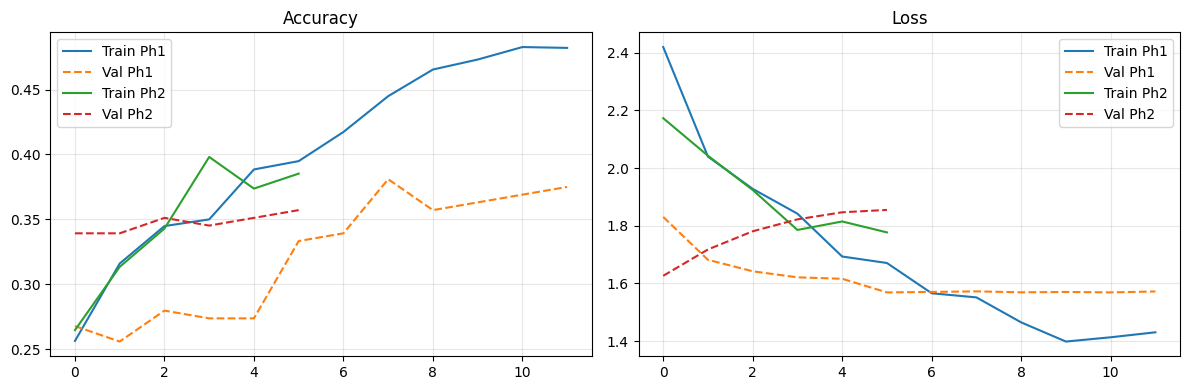

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h1.history["accuracy"],     label="Train Ph1")
ax[0].plot(h1.history["val_accuracy"], label="Val Ph1",  linestyle="--")
ax[0].plot(h2.history["accuracy"],     label="Train Ph2")
ax[0].plot(h2.history["val_accuracy"], label="Val Ph2",  linestyle="--")
ax[0].set_title("Accuracy"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(h1.history["loss"],     label="Train Ph1")
ax[1].plot(h1.history["val_loss"], label="Val Ph1",  linestyle="--")
ax[1].plot(h2.history["loss"],     label="Train Ph2")
ax[1].plot(h2.history["val_loss"], label="Val Ph2",  linestyle="--")
ax[1].set_title("Loss"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()




STEP 7 - Testing on test images...

--- bacterial_acne (72 images) ---
  [CORRECT]  1.jpg                                Predicted: bacterial_acne          (95.3%)
  [CORRECT]  10.jpg                               Predicted: bacterial_acne          (85.2%)
  [CORRECT]  11.jpg                               Predicted: bacterial_acne          (47.5%)
  [WRONG]  12.jpg                               Predicted: dietary_acne            (57.2%)
  [WRONG]  13.jpg                               Predicted: hormonal_acne           (32.9%)
  [WRONG]  14.jpg                               Predicted: dietary_acne            (42.1%)
  [WRONG]  15.jpg                               Predicted: dietary_acne            (44.1%)
  [CORRECT]  16.jpg                               Predicted: bacterial_acne          (30.1%)
  [WRONG]  17.jpg                               Predicted: dietary_acne            (44.3%)
  [WRONG]  18.jpg                               Predicted: dietary_acne            (44.3%)
  [CORRECT

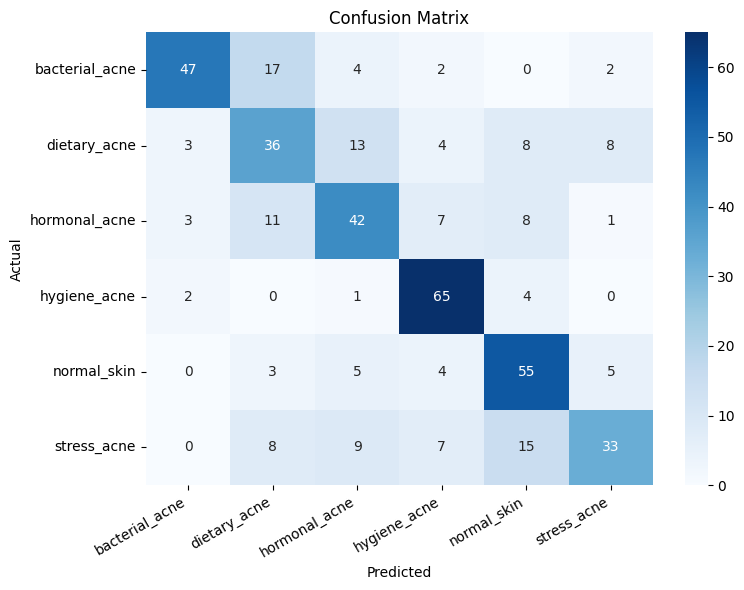


Done! now you can predict your own images.


In [36]:
print("\nSTEP 7 - Testing on test images...")

all_true, all_pred = [], []

for cls in CLASS_NAMES:
    cls_folder = os.path.join(TEST_DIR, cls)
    if not os.path.isdir(cls_folder):
        continue

    images = [f for f in os.listdir(cls_folder)
               if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    print(f"\n--- {cls} ({len(images)} images) ---")

    for img_name in images:
        img_path  = os.path.join(cls_folder, img_name)
        img       = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
        # SAME preprocessing as training
        img_array = preprocess_input(np.array(img, dtype=np.float32))
        img_array = np.expand_dims(img_array, axis=0)

        pred     = model.predict(img_array, verbose=0)
        pred_idx = np.argmax(pred)
        true_idx = CLASS_NAMES.index(cls)
        conf     = pred[0][pred_idx] * 100
        result   = "CORRECT" if pred_idx == true_idx else "WRONG"

        print(f"  [{result}]  {img_name:<35}"
              f"  Predicted: {CLASS_NAMES[pred_idx]:<22}  ({conf:.1f}%)")

        all_true.append(true_idx)
        all_pred.append(pred_idx)

acc = (np.array(all_true) == np.array(all_pred)).mean() * 100
print(f"\n{'=' * 55}")
print(f"  Total Images  : {len(all_true)}")
print(f"  Test Accuracy : {acc:.2f}%")
print(f"{'=' * 55}")
print(classification_report(all_true, all_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(all_true, all_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("\nDone! now you can predict your own images.")